In [1]:
print("Alzheimer's EEG Project")

Alzheimer's EEG Project


In [2]:
import mne
import numpy as np
import matplotlib.pyplot as plt

In [3]:
print("MNE version:", mne.__version__)
print("NumPy version:", np.__version__)

MNE version: 1.13.2
NumPy version: 2.5.3


In [4]:
import sys

print("Python version:", sys.version)
print("Python location:", sys.executable)

Python version: 3.12.14 | packaged by Anaconda, Inc. | (main, Aug 27 2026, 14:37:13) [MSC v.1942 64 bit (AMD64)]
Python location: C:\Users\Saunak Das\miniconda3\envs\alzheimer_eeg\python.exe


In [5]:
from pathlib import Path

In [6]:
data_path = Path("../data")

In [7]:
print(data_path.exists())

True


In [8]:
for item in data_path.iterdir():
    print(item.name)

.datalad
.gitattributes
CHANGES
dataset_description.json
derivatives
participants.json
participants.tsv
README
sub-001
sub-002
sub-003
sub-004
sub-005
sub-006
sub-007
sub-008
sub-009
sub-010
sub-011
sub-012
sub-013
sub-014
sub-015
sub-016
sub-017
sub-018
sub-019
sub-020
sub-021
sub-022
sub-023
sub-024
sub-025
sub-026
sub-027
sub-028
sub-029
sub-030
sub-031
sub-032
sub-033
sub-034
sub-035
sub-036
sub-037
sub-038
sub-039
sub-040
sub-041
sub-042
sub-043
sub-044
sub-045
sub-046
sub-047
sub-048
sub-049
sub-050
sub-051
sub-052
sub-053
sub-054
sub-055
sub-056
sub-057
sub-058
sub-059
sub-060
sub-061
sub-062
sub-063
sub-064
sub-065
sub-066
sub-067
sub-068
sub-069
sub-070
sub-071
sub-072
sub-073
sub-074
sub-075
sub-076
sub-077
sub-078
sub-079
sub-080
sub-081
sub-082
sub-083
sub-084
sub-085
sub-086
sub-087
sub-088


In [9]:
import pandas as pd

In [10]:
participants = pd.read_csv(data_path / "participants.tsv", sep="\t")

In [11]:
participants.head()

,participant_id,Gender,Age,Group,MMSE
0,sub-001,F,57,A,16
1,sub-002,F,78,A,22
2,sub-003,M,70,A,14
3,sub-004,F,67,A,20
4,sub-005,M,70,A,22


In [12]:
participants.columns

Index(['participant_id', 'Gender', 'Age', 'Group', 'MMSE'], dtype='str')

In [13]:
participants["Group"].unique()

<StringArray>
['A', 'C', 'F']
Length: 3, dtype: str

In [14]:
participants["Group"].value_counts()

Group
A    36
C    29
F    23
Name: count, dtype: int64

In [15]:
subject_path = data_path / "sub-001"

In [16]:
for item in subject_path.iterdir():
    print(item.name)

eeg


In [17]:
eeg_path = subject_path / "eeg"

In [18]:
for item in eeg_path.iterdir():
    print(item.name)

sub-001_task-eyesclosed_channels.tsv
sub-001_task-eyesclosed_eeg.json
sub-001_task-eyesclosed_eeg.set


In [19]:
eeg_file = eeg_path / "sub-001_task-eyesclosed_eeg.set"

In [20]:
raw = mne.io.read_raw_eeglab(eeg_file, preload=False)

Reading C:\Users\Saunak Das\alzheimers-eeg-ml\notebooks\..\data\sub-001\eeg\sub-001_task-eyesclosed_eeg.set


In [21]:
print(raw)

<RawEEGLAB | sub-001_task-eyesclosed_eeg.set, 19 x 299900 (599.8 s), ~26 KiB, data not loaded>


In [22]:
print(raw.info["sfreq"])

500.0


In [23]:
print(raw.ch_names)

['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']


In [24]:
print(raw.info.keys())

dict_keys(['acq_pars', 'acq_stim', 'ctf_head_t', 'description', 'dev_head_t', 'dev_ctf_t', 'dig', 'experimenter', 'utc_offset', 'device_info', 'file_id', 'highpass', 'hpi_subsystem', 'kit_system_id', 'helium_info', 'line_freq', 'lowpass', 'meas_date', 'meas_id', 'proj_id', 'proj_name', 'subject_info', 'xplotter_layout', 'gantry_angle', 'bads', 'chs', 'comps', 'events', 'hpi_meas', 'hpi_results', 'projs', 'proc_history', 'custom_ref_applied', 'sfreq', 'ch_names', 'nchan'])


In [25]:
print(raw.info["nchan"])

19


In [26]:
print(raw.info["bads"])

[]


In [27]:
print("High-pass:", raw.info["highpass"])
print("Low-pass:", raw.info["lowpass"])

High-pass: 0.0
Low-pass: 250.0


In [28]:
print("Line frequency:", raw.info["line_freq"])

Line frequency: None


In [29]:
print(raw.info["meas_date"])

None


In [30]:
raw.get_data(start=0, stop=10).shape

(19, 10)

In [31]:
data = raw.get_data(start=0, stop=10)

In [32]:
print(data.shape)

(19, 10)


In [33]:
print(data)

[[-1.89892563e-04 -1.80419907e-04 -1.66992172e-04 -1.60205063e-04
  -1.59326157e-04 -1.54296860e-04 -1.71093735e-04 -1.83544907e-04
  -1.81542953e-04 -1.75927719e-04]
 [-1.41845688e-04 -1.37353500e-04 -1.35058578e-04 -1.32958969e-04
  -1.24462883e-04 -1.15820305e-04 -1.26074211e-04 -1.34326157e-04
  -1.36425766e-04 -1.33056625e-04]
 [-1.07373039e-04 -1.00048820e-04 -1.05761711e-04 -1.05322258e-04
  -1.04150383e-04 -9.73632736e-05 -1.04785149e-04 -1.16455070e-04
  -1.21972649e-04 -1.15576164e-04]
 [ 2.84667988e-05  3.22753906e-05  3.53515625e-05  3.80371094e-05
   4.11621094e-05  5.11718750e-05  4.57031212e-05  3.93066406e-05
   3.40820313e-05  3.92089844e-05]
 [-1.08447258e-04 -1.03369133e-04 -1.01953117e-04 -9.97558517e-05
  -9.84863205e-05 -8.97460937e-05 -9.71679611e-05 -1.04248039e-04
  -1.07617180e-04 -1.03955070e-04]
 [-3.64746094e-05 -3.36425781e-05 -2.98828125e-05 -2.70996075e-05
  -2.44628906e-05 -1.32812519e-05 -1.69921894e-05 -2.54394512e-05
  -3.12499981e-05 -2.50488262e-05

In [34]:
print(raw.get_montage())

<DigMontage | 0 extras (headshape), 0 HPIs, 3 fiducials, 19 channels>


In [35]:
positions = raw.get_montage().get_positions()["ch_pos"]

In [36]:
print(type(positions))
print(len(positions))

<class 'collections.OrderedDict'>
19


In [37]:
print(positions["Fp1"])

[-0.0294367  0.0839171 -0.00699  ]


In [38]:
print(raw.get_montage().get_positions()["coord_frame"])

head


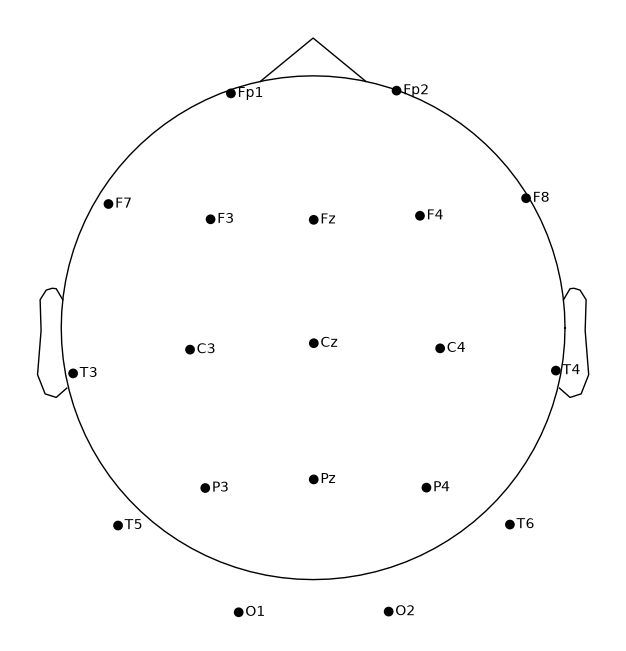

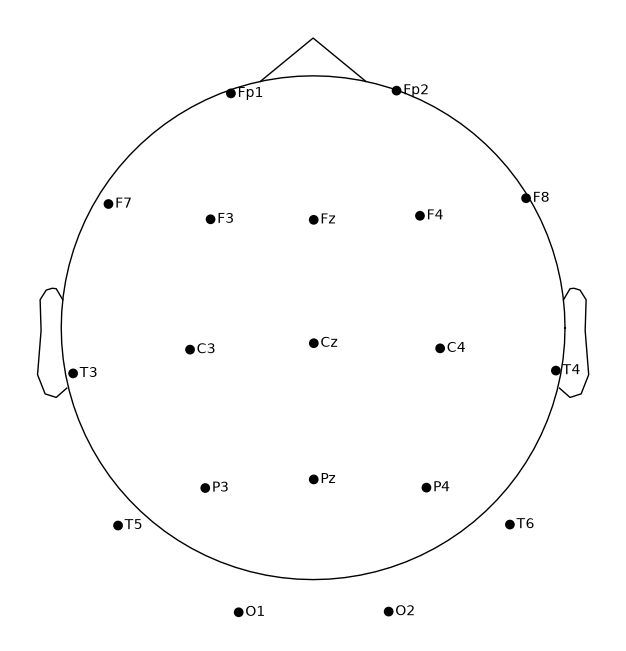

In [39]:
raw.get_montage().plot()

Using matplotlib as 2D backend.
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


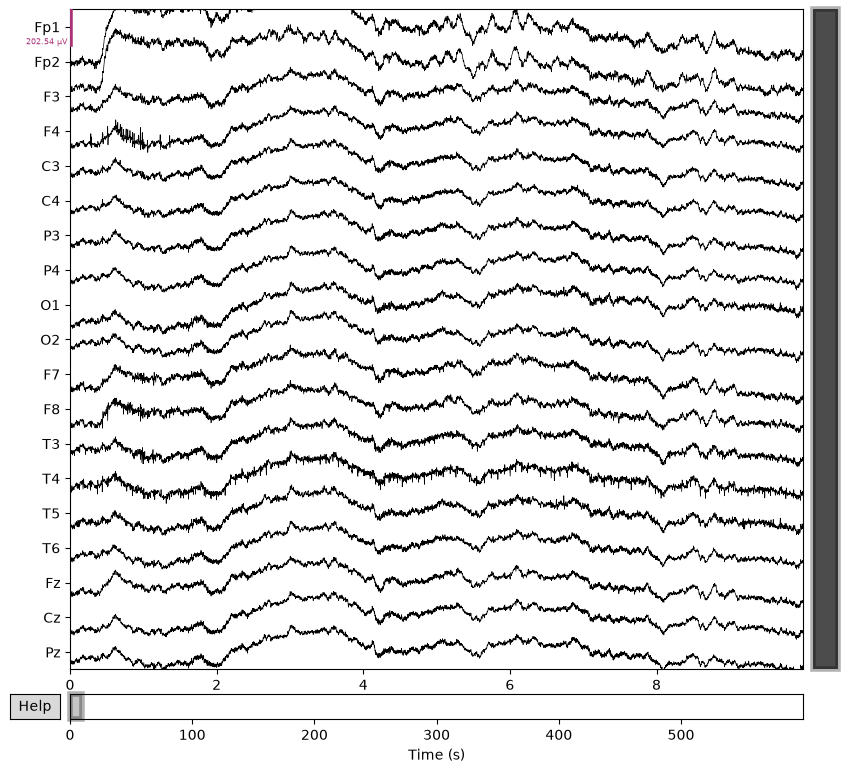

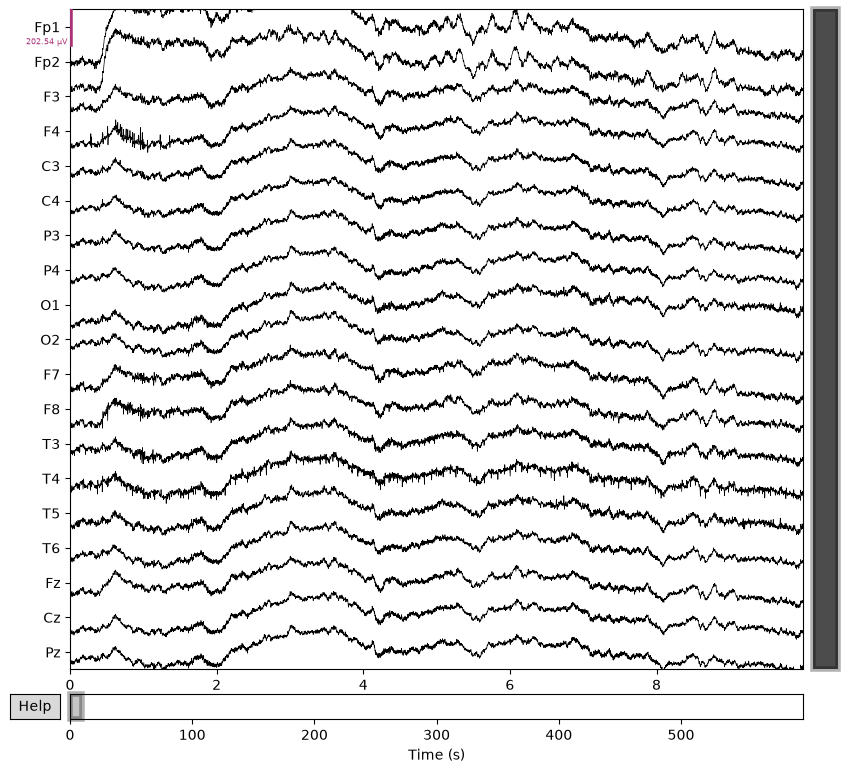

In [40]:
raw.plot(duration=10, n_channels=19, scalings="auto")

In [41]:
%matplotlib qt

For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


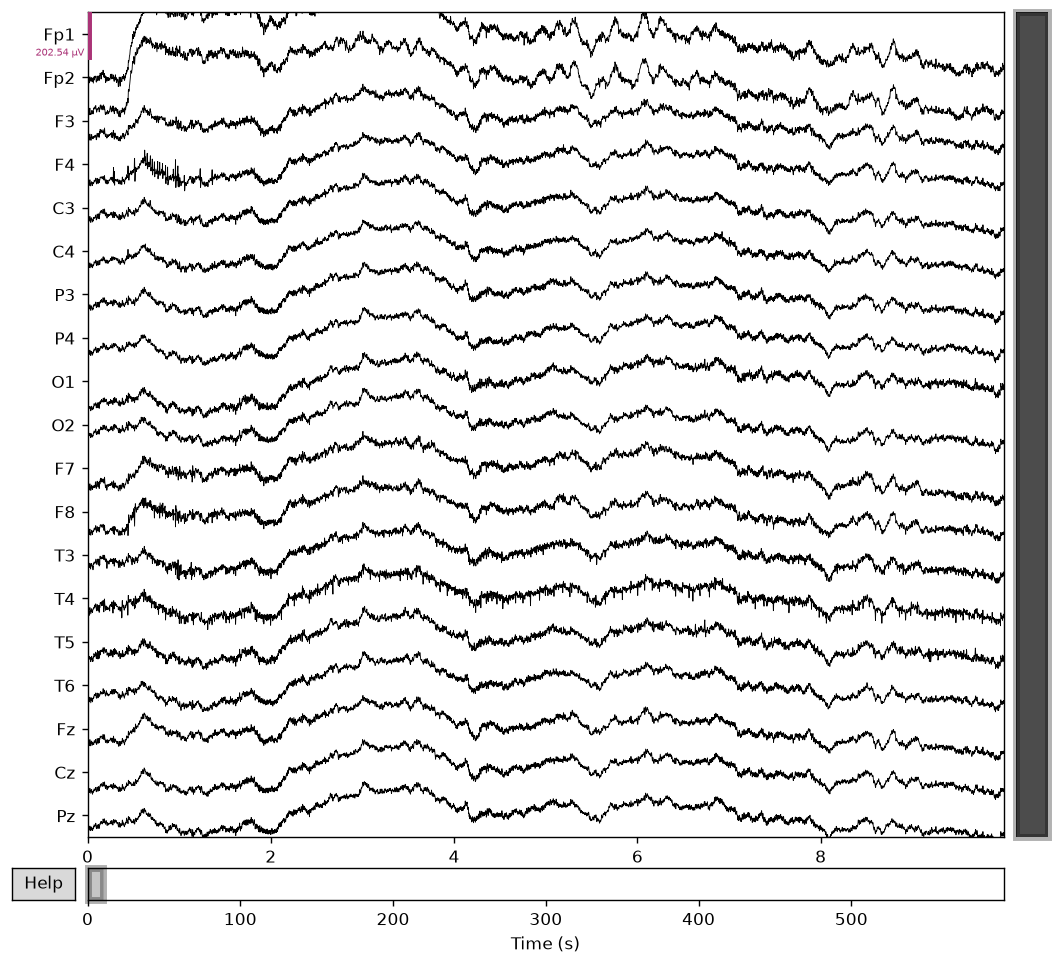

Channels marked as bad:
none


In [42]:
raw.plot(duration=10, n_channels=19, scalings="auto")

In [43]:
print(raw.get_channel_types())

['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg']


In [44]:
data = raw.get_data()
print("Minimum:", data.min())
print("Maximum:", data.max())

Minimum: -0.00046611325073242185
Maximum: 0.0028796384277343747


In [45]:
print("Mean:", data.mean())
print("Standard deviation:", data.std())

Mean: 3.3488209181823e-05
Standard deviation: 0.00011126369084712183


For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


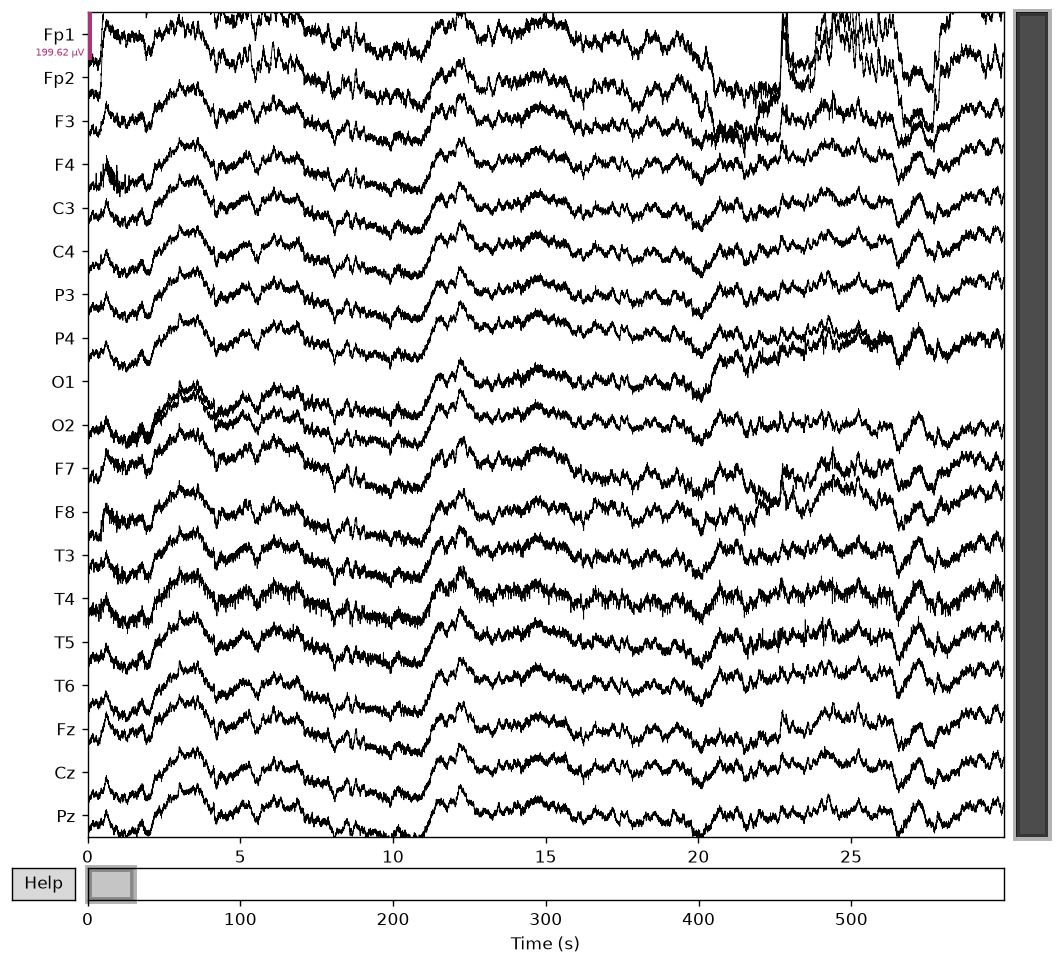

Channels marked as bad:
none


In [46]:
raw.plot(duration=30, n_channels=19, scalings="auto")

In [47]:
print(raw.info["custom_ref_applied"])

0 (FIFFV_MNE_CUSTOM_REF_OFF)


In [48]:
print(raw.info["chs"][0])

{'loc': array([-0.0294367,  0.0839171, -0.00699  ,  0.       ,  0.       ,
        0.       ,        nan,        nan,        nan,        nan,
              nan,        nan]), 'unit_mul': 0 (FIFF_UNITM_NONE), 'range': 1.0, 'cal': 1e-06, 'kind': 2 (FIFFV_EEG_CH), 'coil_type': 1 (FIFFV_COIL_EEG), 'unit': 107 (FIFF_UNIT_V), 'coord_frame': 4 (FIFFV_COORD_HEAD), 'ch_name': 'Fp1', 'scanno': 1, 'logno': 1}


In [49]:
print(raw.info["projs"])

[]


In [50]:
import json

with open(eeg_path / "sub-001_task-eyesclosed_eeg.json") as f:
    eeg_info = json.load(f)

print(eeg_info)

{'PowerLineFrequency': 50, 'SoftwareFilters': {'FilterDescription': {'Description': '0.4 - 50'}}, 'EEGPlacementScheme': '10-20', 'EEGReference': 'A1 A2', 'CapManufacturersModelName': 'EEG 2100', 'CapManufacturer': 'Nihon Kohden', 'InstitutionAddress': 'Arta, Greece', 'InstitutionalDepartmentName': 'Department of Informatics and Telecommunications', 'InstitutionName': 'University of Ioannina', 'TaskName': 'eyesclosed', 'EEGChannelCount': 19, 'RecordingType': 'continuous', 'RecordingDuration': 599.8, 'SamplingFrequency': 500, 'EOGChannelCount': 0, 'ECGChannelCount': 0, 'EMGChannelCount': 0}


In [51]:
raw_filtered = raw.copy()

In [52]:
raw_filtered.load_data()

Reading 0 ... 299899  =      0.000 ...   599.798 secs...


<RawEEGLAB | sub-001_task-eyesclosed_eeg.set, 19 x 299900 (599.8 s), ~43.5 MiB, data loaded>

In [53]:
print(raw_filtered.preload)

True


Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


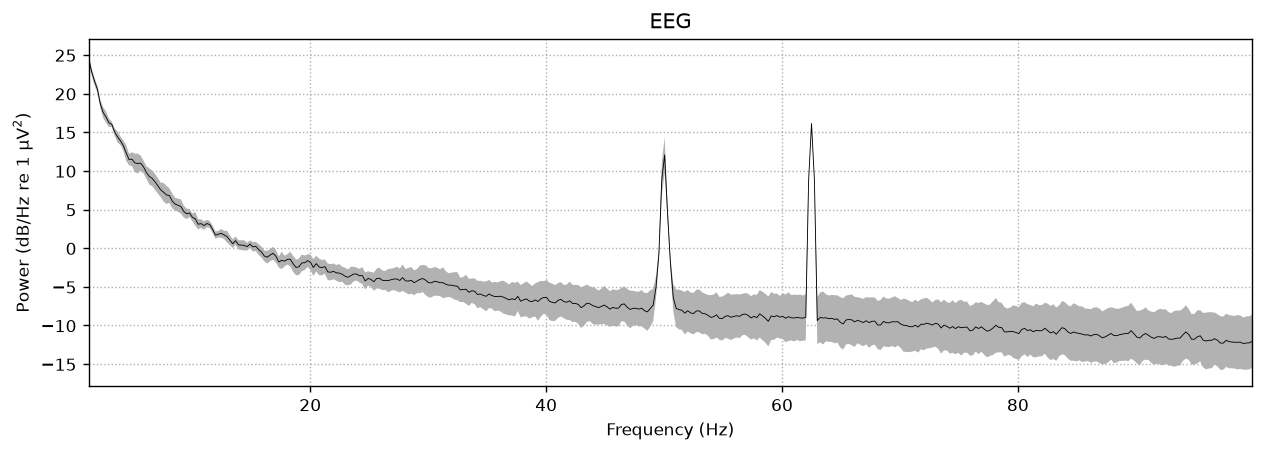

In [54]:
psd_1_100 = raw_filtered.compute_psd(
    method="welch",
    fmin=1,
    fmax=100
)

psd_1_100.plot(average=True)

Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


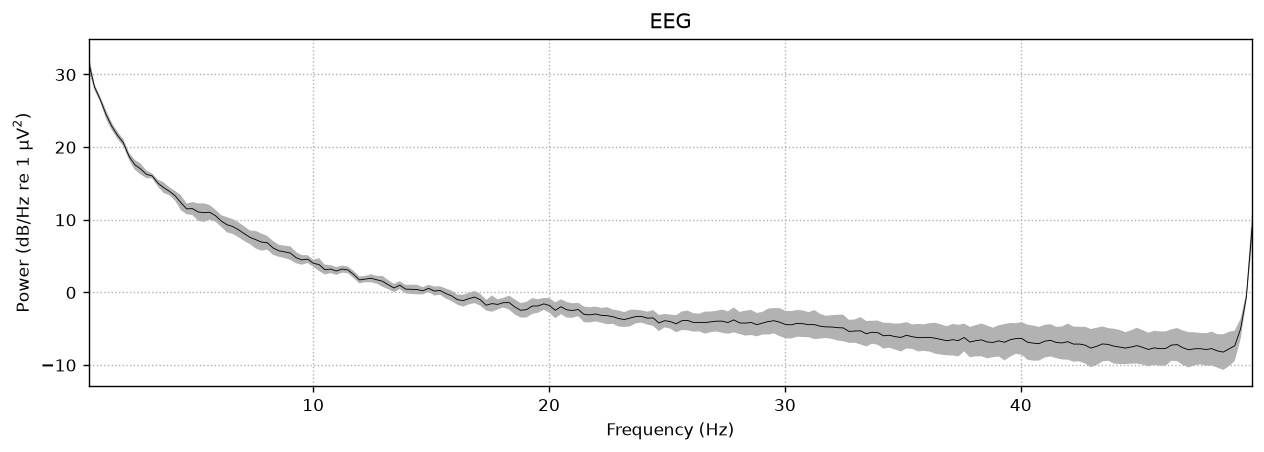

In [55]:
psd_04_50 = raw_filtered.compute_psd(
    method="welch",
    fmin=0.4,
    fmax=50
)

psd_04_50.plot(average=True)

In [56]:
print(psd_1_100.freqs[(psd_1_100.freqs >= 45) & (psd_1_100.freqs <= 55)])

[45.16601562 45.41015625 45.65429688 45.8984375  46.14257812 46.38671875
 46.63085938 46.875      47.11914062 47.36328125 47.60742188 47.8515625
 48.09570312 48.33984375 48.58398438 48.828125   49.07226562 49.31640625
 49.56054688 49.8046875  50.04882812 50.29296875 50.53710938 50.78125
 51.02539062 51.26953125 51.51367188 51.7578125  52.00195312 52.24609375
 52.49023438 52.734375   52.97851562 53.22265625 53.46679688 53.7109375
 53.95507812 54.19921875 54.44335938 54.6875     54.93164062]


In [58]:
idx = np.where((psd_1_100.freqs >= 45) & (psd_1_100.freqs <= 55))[0]

peak_idx = idx[np.argmax(psd_1_100.get_data()[:, idx].mean(axis=0))]

print("Peak frequency:", psd_1_100.freqs[peak_idx])

Peak frequency: 50.048828125


In [59]:
raw_notched = raw_filtered.copy()

In [60]:
raw_notched.notch_filter(freqs=50)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 3301 samples (6.602 s)



<RawEEGLAB | sub-001_task-eyesclosed_eeg.set, 19 x 299900 (599.8 s), ~43.5 MiB, data loaded>

In [61]:
psd_notched = raw_notched.compute_psd(
    method="welch",
    fmin=1,
    fmax=100
)

Effective window size : 4.096 (s)


In [62]:
idx = np.where(
    (psd_notched.freqs >= 45) &
    (psd_notched.freqs <= 55)
)[0]

peak_idx = idx[
    np.argmax(
        psd_notched.get_data()[:, idx].mean(axis=0)
    )
]

print("Peak frequency after notch:", psd_notched.freqs[peak_idx])
print("Peak power after notch:", psd_notched.get_data()[:, peak_idx].mean())

Peak frequency after notch: 50.537109375
Peak power after notch: 3.4295237556505824e-13


Plotting power spectral density (dB=True).


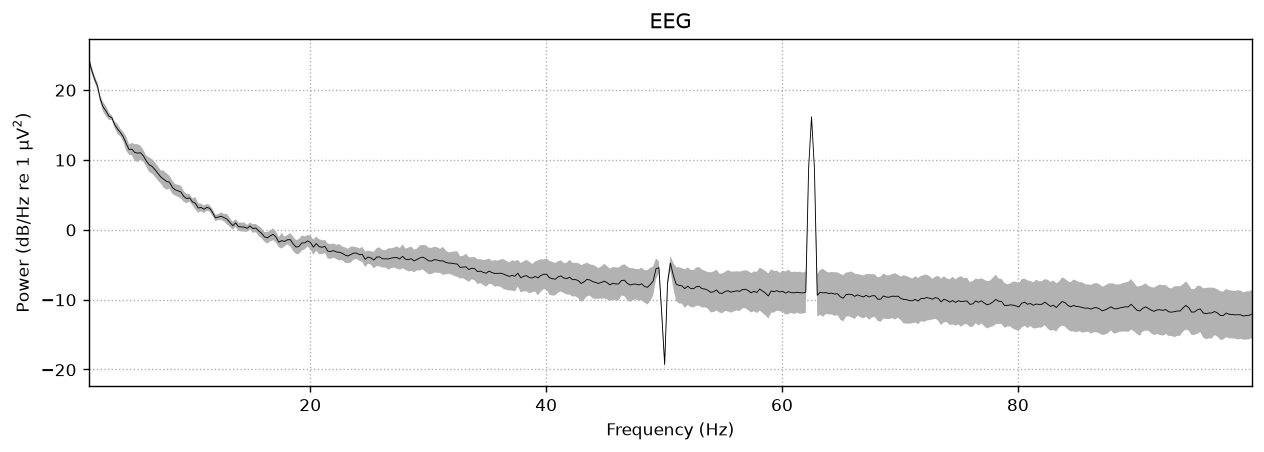

In [63]:
psd_notched.plot(average=True)

In [66]:
idx_60_65 = np.where(
    (psd_notched.freqs >= 60) &
    (psd_notched.freqs <= 65)
)[0]

peak_idx_60_65 = idx_60_65[
    np.argmax(
        psd_notched.get_data()[:, idx_60_65].mean(axis=0)
    )
]

print("Peak frequency:", psd_notched.freqs[peak_idx_60_65])
print("Peak power:", psd_notched.get_data()[:, peak_idx_60_65].mean())

Peak frequency: 62.5
Peak power: 4.1117979123098414e-11


In [67]:
channel_power_62_5 = psd_notched.get_data()[:, peak_idx_60_65]

for ch, power in zip(raw_notched.ch_names, channel_power_62_5):
    print(ch, power)

Fp1 4.151116822070693e-11
Fp2 4.1583456777521896e-11
F3 4.08215857768793e-11
F4 4.0914280315015044e-11
C3 4.082788456804955e-11
C4 4.088447958241726e-11
P3 4.0754431960025606e-11
P4 4.080760243666872e-11
O1 4.119667262603721e-11
O2 4.1006869544716946e-11
F7 4.247557183031068e-11
F8 4.1634308299330525e-11
T3 4.103842332492721e-11
T4 4.1353497794369415e-11
T5 4.083095110664248e-11
T6 4.086845651935078e-11
Fz 4.1116360699756136e-11
Cz 4.07702805385131e-11
Pz 4.0845321417631006e-11


In [68]:
print(psd_notched.freqs[peak_idx_60_65])

62.5


In [69]:
print(psd_notched.freqs[(psd_notched.freqs >= 60) & (psd_notched.freqs <= 65)])

[60.05859375 60.30273438 60.546875   60.79101562 61.03515625 61.27929688
 61.5234375  61.76757812 62.01171875 62.25585938 62.5        62.74414062
 62.98828125 63.23242188 63.4765625  63.72070312 63.96484375 64.20898438
 64.453125   64.69726562 64.94140625]


In [70]:
mask_60_65 = (psd_notched.freqs >= 60) & (psd_notched.freqs <= 65)

freqs_60_65 = psd_notched.freqs[mask_60_65]

power_60_65 = psd_notched.get_data()[:, mask_60_65].mean(axis=0)

for freq, power in zip(freqs_60_65, power_60_65):
    print(freq, power)

60.05859375 1.6363582689691668e-13
60.302734375 1.5801874947591088e-13
60.546875 1.6676966458829686e-13
60.791015625 1.556200082074794e-13
61.03515625 1.5631842813324965e-13
61.279296875 1.578517233618143e-13
61.5234375 1.5862831831103404e-13
61.767578125 1.5458971206181037e-13
62.01171875 1.5941956568803773e-13
62.255859375 7.671594517155e-12
62.5 4.1117979123098414e-11
62.744140625 7.63701768144816e-12
62.98828125 1.456471859104515e-13
63.232421875 1.6476445000058223e-13
63.4765625 1.6869985512483464e-13
63.720703125 1.602486265927412e-13
63.96484375 1.5334229577050388e-13
64.208984375 1.5544076793363164e-13
64.453125 1.528040673178411e-13
64.697265625 1.5269950815878085e-13
64.94140625 1.4264756960646564e-13


For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


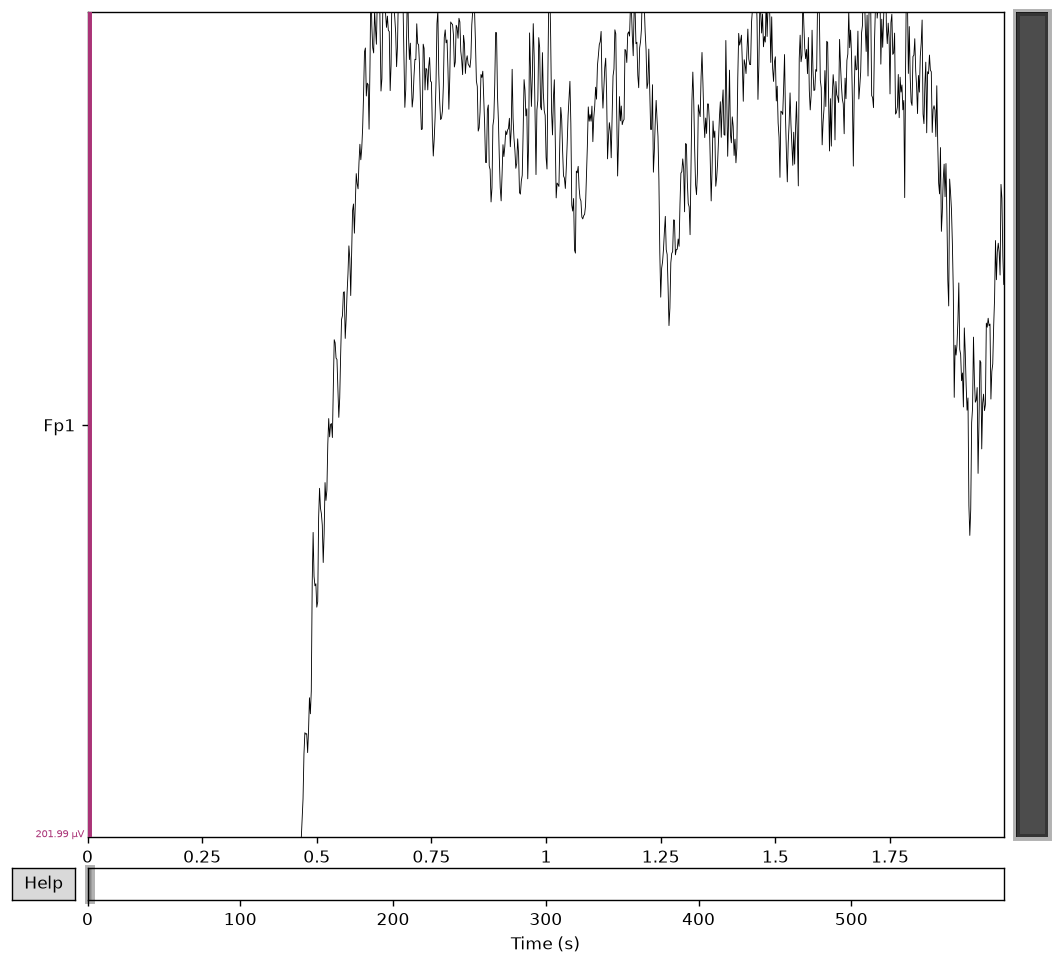

Channels marked as bad:
none


In [71]:
raw_notched.plot(
    picks="Fp1",
    duration=2,
    scalings="auto"
)

For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


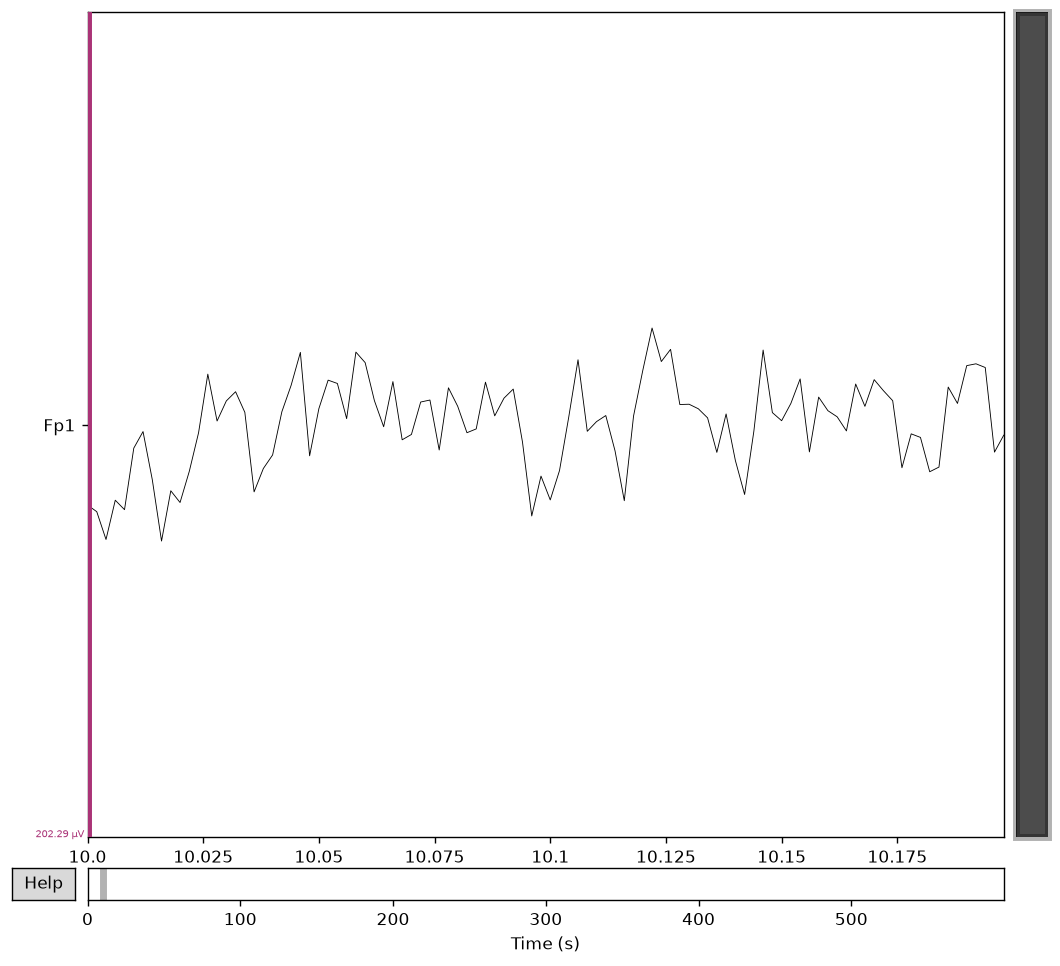

Channels marked as bad:
none


In [72]:
raw_notched.plot(
    picks="Fp1",
    start=10,
    duration=0.2,
    scalings="auto"
)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 60 - 65 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 60.00
- Lower transition bandwidth: 15.00 Hz (-6 dB cutoff frequency: 52.50 Hz)
- Upper passband edge: 65.00 Hz
- Upper transition bandwidth: 16.25 Hz (-6 dB cutoff frequency: 73.12 Hz)
- Filter length: 111 samples (0.222 s)

For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


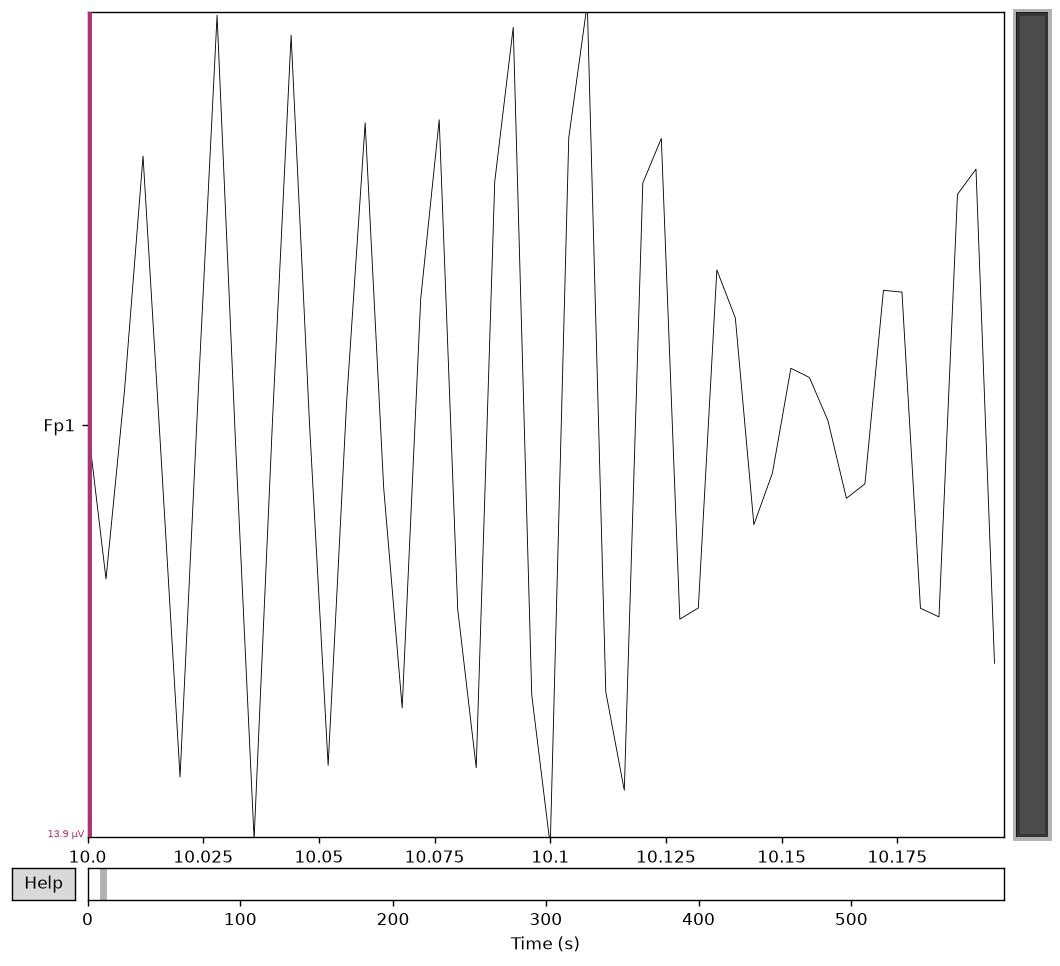

Channels marked as bad:
none


In [73]:
raw_62 = raw_notched.copy()

raw_62.filter(l_freq=60, h_freq=65)

raw_62.plot(
    picks="Fp1",
    start=10,
    duration=0.2,
    scalings="auto"
)

In [74]:
print(
    "62.5 Hz power before notch:",
    psd_1_100.get_data()[:, peak_idx_60_65].mean()
)

print(
    "62.5 Hz power after notch:",
    psd_notched.get_data()[:, peak_idx_60_65].mean()
)

62.5 Hz power before notch: 4.1135643486413095e-11
62.5 Hz power after notch: 4.1117979123098414e-11


In [75]:
epochs = mne.make_fixed_length_epochs(
    raw_notched,
    duration=4.0,
    overlap=0,
    preload=True
)

Not setting metadata
149 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 149 events and 2000 original time points ...
0 bad epochs dropped


In [76]:
print(epochs.get_data().shape)

(149, 19, 2000)


For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


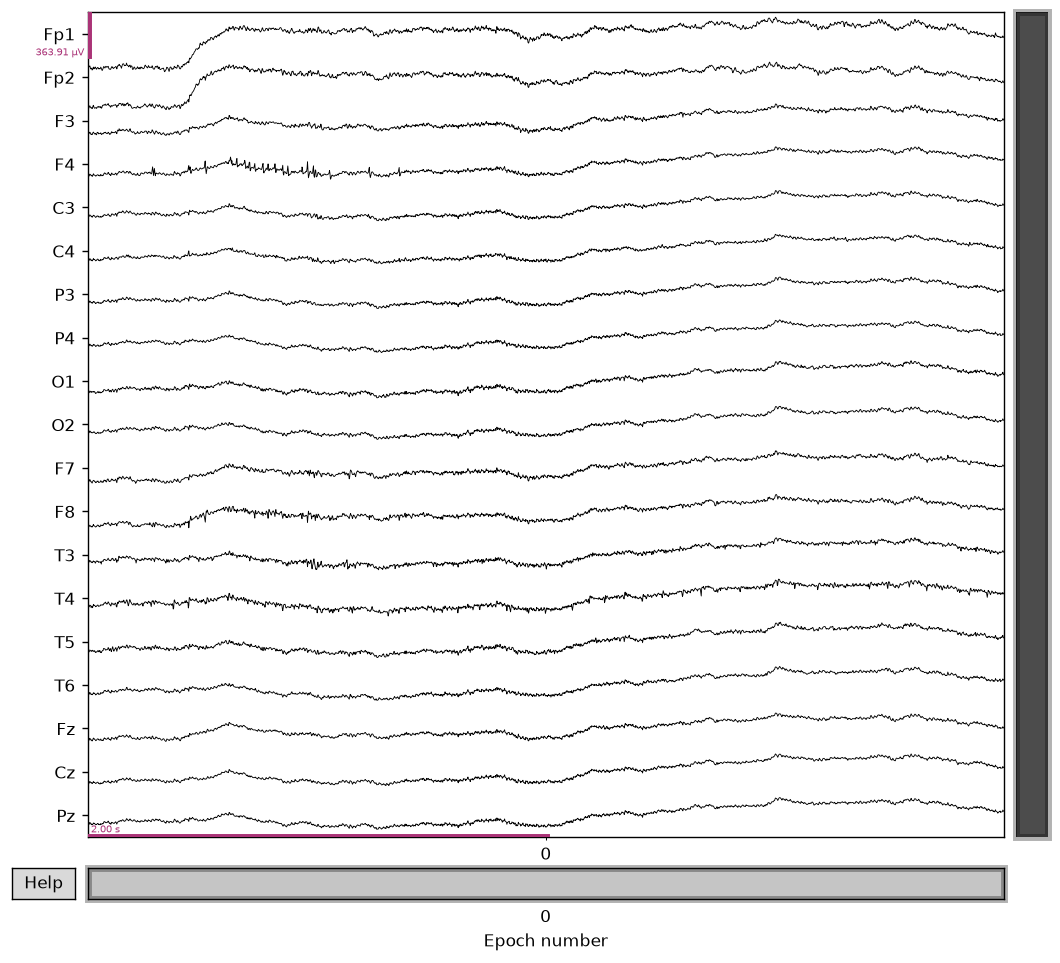

Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none


In [77]:
epochs[0].plot(n_channels=19, scalings="auto")

In [78]:
epochs_psd = epochs.compute_psd(
    method="welch",
    fmin=1,
    fmax=45
)

Effective window size : 4.000 (s)


In [79]:
print(epochs_psd.get_data().shape)

(149, 19, 177)


In [80]:
print(epochs_psd.freqs[:10])
print(epochs_psd.freqs[-10:])

[1.   1.25 1.5  1.75 2.   2.25 2.5  2.75 3.   3.25]
[42.75 43.   43.25 43.5  43.75 44.   44.25 44.5  44.75 45.  ]


In [81]:
bands = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45)
}

In [82]:
alpha_mask = (
    (epochs_psd.freqs >= 8) &
    (epochs_psd.freqs < 13)
)

alpha_power = np.trapezoid(
    epochs_psd.get_data()[:, :, alpha_mask],
    x=epochs_psd.freqs[alpha_mask],
    axis=-1
)

In [83]:
print(alpha_power.shape)

(149, 19)


In [90]:
band_power = {}

psd_data = epochs_psd.get_data()
freqs = epochs_psd.freqs

for band, (fmin, fmax) in bands.items():
    mask = (freqs >= fmin) & (freqs <= fmax)
    
    band_power[band] = np.trapezoid(
        psd_data[:, :, mask],
        x=freqs[mask],
        axis=-1
    )

In [91]:
for band, power in band_power.items():
    print(band, power.shape)

delta (149, 19)
theta (149, 19)
alpha (149, 19)
beta (149, 19)
gamma (149, 19)


In [92]:
total_power = np.trapezoid(
    psd_data,
    x=freqs,
    axis=-1
)

In [93]:
relative_power = {}

for band, power in band_power.items():
    relative_power[band] = power / total_power

In [94]:
print(relative_power["alpha"].shape)
print(relative_power["alpha"][0])

(149, 19)
[0.03401258 0.03006455 0.02768289 0.02631472 0.02987124 0.02451515
 0.03086454 0.03056313 0.04133696 0.03358311 0.02566571 0.02737229
 0.03229704 0.02949101 0.04005333 0.03030929 0.02775148 0.02771623
 0.02733577]


In [95]:
print(
    relative_power["delta"][0, 0]
    + relative_power["theta"][0, 0]
    + relative_power["alpha"][0, 0]
    + relative_power["beta"][0, 0]
    + relative_power["gamma"][0, 0]
)

1.0


In [96]:
for band in relative_power:
    print(band, relative_power[band][0, 0])

delta 0.7242929763543994
theta 0.1966608759908996
alpha 0.03401257998782328
beta 0.02697965294643541
gamma 0.018053914720442352


In [97]:
epoch_features = {}

for band in relative_power:
    epoch_features[band] = relative_power[band].mean(axis=1)

epoch_features = pd.DataFrame(epoch_features)

print(epoch_features.shape)

(149, 5)


In [98]:
print(epoch_features.head())

      delta     theta     alpha      beta     gamma
0  0.836031  0.086330  0.030358  0.031543  0.015738
1  0.792678  0.129846  0.030750  0.033570  0.013157
2  0.690890  0.156520  0.065030  0.065621  0.021939
3  0.678478  0.200162  0.038054  0.059418  0.023888
4  0.786144  0.130374  0.034230  0.035528  0.013724


In [99]:
print(epoch_features.describe())

            delta       theta       alpha        beta       gamma
count  149.000000  149.000000  149.000000  149.000000  149.000000
mean     0.793146    0.126229    0.036754    0.032262    0.011609
std      0.074184    0.050380    0.017022    0.012603    0.004935
min      0.527792    0.031904    0.011975    0.012399    0.004150
25%      0.739746    0.088520    0.025980    0.023314    0.008026
50%      0.801576    0.121256    0.033097    0.030568    0.010438
75%      0.845645    0.159718    0.040955    0.037236    0.013899
max      0.925613    0.290218    0.106474    0.072647    0.029256


In [101]:
%matplotlib inline

<Axes: >

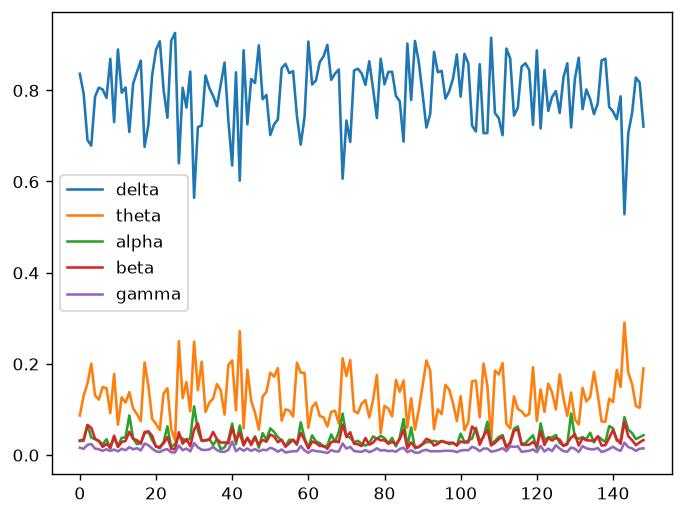

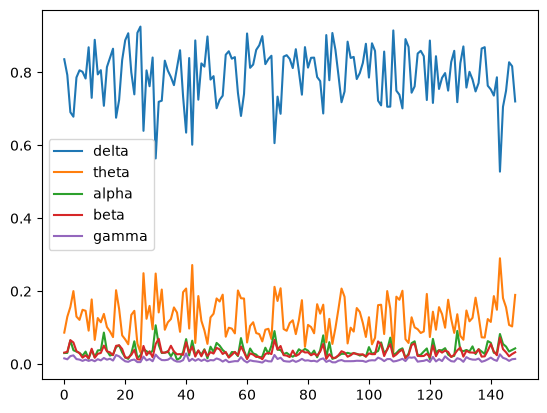

In [102]:
epoch_features.plot()

In [103]:
epoch_features["subject"] = "sub-001"

In [104]:
epoch_features["group"] = "A"

In [105]:
subject_info = participants[participants["participant_id"] == "sub-001"].iloc[0]

epoch_features["age"] = subject_info["Age"]
epoch_features["MMSE"] = subject_info["MMSE"]

In [106]:
print(epoch_features.head())

      delta     theta     alpha      beta     gamma  subject group  age  MMSE
0  0.836031  0.086330  0.030358  0.031543  0.015738  sub-001     A   57    16
1  0.792678  0.129846  0.030750  0.033570  0.013157  sub-001     A   57    16
2  0.690890  0.156520  0.065030  0.065621  0.021939  sub-001     A   57    16
3  0.678478  0.200162  0.038054  0.059418  0.023888  sub-001     A   57    16
4  0.786144  0.130374  0.034230  0.035528  0.013724  sub-001     A   57    16


In [107]:
subject_features = epoch_features[
    ["delta", "theta", "alpha", "beta", "gamma"]
].mean()

In [108]:
print(subject_features)

delta    0.793146
theta    0.126229
alpha    0.036754
beta     0.032262
gamma    0.011609
dtype: float64


In [109]:
subject_features = pd.DataFrame([subject_features])

subject_features["subject"] = "sub-001"
subject_features["group"] = "A"
subject_features["age"] = subject_info["Age"]
subject_features["MMSE"] = subject_info["MMSE"]

In [110]:
print(subject_features)

      delta     theta     alpha      beta     gamma  subject group  age  MMSE
0  0.793146  0.126229  0.036754  0.032262  0.011609  sub-001     A   57    16


In [111]:
print(subject_features.isna().sum())

delta      0
theta      0
alpha      0
beta       0
gamma      0
subject    0
group      0
age        0
MMSE       0
dtype: int64


In [112]:
subject_features.to_csv(
    "../data/sub-001_pilot_features.csv",
    index=False
)

## Pilot Analysis — sub-001

Subject `sub-001` was used to develop and verify the EEG preprocessing and feature-extraction pipeline before applying it to the full dataset.

### Processing performed

- Inspected EEG metadata, channel information, and electrode locations.
- Confirmed the recording contains 19 scalp EEG channels sampled at 500 Hz.
- Examined the raw EEG signal and its power spectral density (PSD).
- Identified a strong ~50 Hz component consistent with the dataset's documented 50 Hz power-line frequency.
- Applied a 50 Hz notch filter and verified that the 50 Hz component was strongly suppressed.
- Observed a narrow 62.5 Hz spectral component. It was not removed because its source could not be established from the available metadata.
- Divided the continuous recording into 4-second non-overlapping epochs.
- Computed PSD for 1–45 Hz.
- Extracted delta, theta, alpha, beta, and gamma band power.
- Converted band power to relative power by dividing by total 1–45 Hz power.
- Averaged relative power across the 19 electrodes for each epoch.
- Averaged across epochs to obtain one subject-level feature vector.

### Pilot output

For `sub-001`, the final subject-level feature vector contained:

- Delta
- Theta
- Alpha
- Beta
- Gamma
- Subject ID
- Diagnostic group
- Age
- MMSE

The pilot was used to validate the processing workflow before scaling the pipeline to all 88 subjects.